# Dataset Inspector

Visual quality inspector for all VLM evaluation tasks.  
Shows sample images, prompts, ground truth, and parameter diversity.

In [1]:
import json
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("../data")
N_EXAMPLES = 5  # samples per task to display
random.seed(42)

# Load all manifests
all_samples = []
for task_dir in sorted(DATA_DIR.iterdir()):
    manifest = task_dir / "manifest.jsonl"
    if not manifest.exists() or task_dir.name in ("baseline", "combined"):
        continue
    with open(manifest) as f:
        for line in f:
            s = json.loads(line.strip())
            all_samples.append(s)

df = pd.DataFrame(all_samples)
print(f"Loaded {len(df)} samples across {df['task_name'].nunique()} tasks")

Loaded 738 samples across 9 tasks


## 1. Dataset Overview

Sample counts and parameter ranges per task.

In [6]:
# Extract params into columns
params_df = pd.json_normalize(df["params"])
params_df.index = df.index

# Columns that contain unhashable types (lists/dicts) — skip in summaries
_SKIP_COLS = {"prompt", "parser", "scorer", "merges", "path", "edges",
              "valid_terminals", "start_box", "terminal_box",
              "path_blue", "path_red", "mode"}

summary_rows = []
for task in sorted(df["task_name"].unique()):
    mask = df["task_name"] == task
    task_params = params_df[mask]
    n = mask.sum()
    gt_vals = df.loc[mask, "ground_truth"].unique()
    gt_preview = ", ".join(sorted(gt_vals)[:8])
    if len(gt_vals) > 8:
        gt_preview += f" ... ({len(gt_vals)} unique)"
    
    # Summarize numeric param ranges
    param_info = []
    for col in task_params.columns:
        if col in _SKIP_COLS:
            continue
        sample_val = task_params[col].dropna().iloc[0] if task_params[col].dropna().any() else None
        if isinstance(sample_val, (list, dict)):
            continue
        try:
            vals = task_params[col].dropna().unique()
        except TypeError:
            continue
        if len(vals) <= 1:
            continue
        try:
            nums = sorted(float(v) for v in vals)
            param_info.append(f"{col}: {nums[0]:.4g}–{nums[-1]:.4g} ({len(nums)} vals)")
        except (ValueError, TypeError):
            param_info.append(f"{col}: {len(vals)} vals")
    
    summary_rows.append({
        "Task": task,
        "Samples": n,
        "GT values": gt_preview,
        "Varying params": "; ".join(param_info) if param_info else "none",
    })

summary_df = pd.DataFrame(summary_rows)


## 2. Per-Task Sample Gallery

For each task, display images with diverse hyperparameters.  
Samples are selected to maximize parameter diversity, not purely at random.

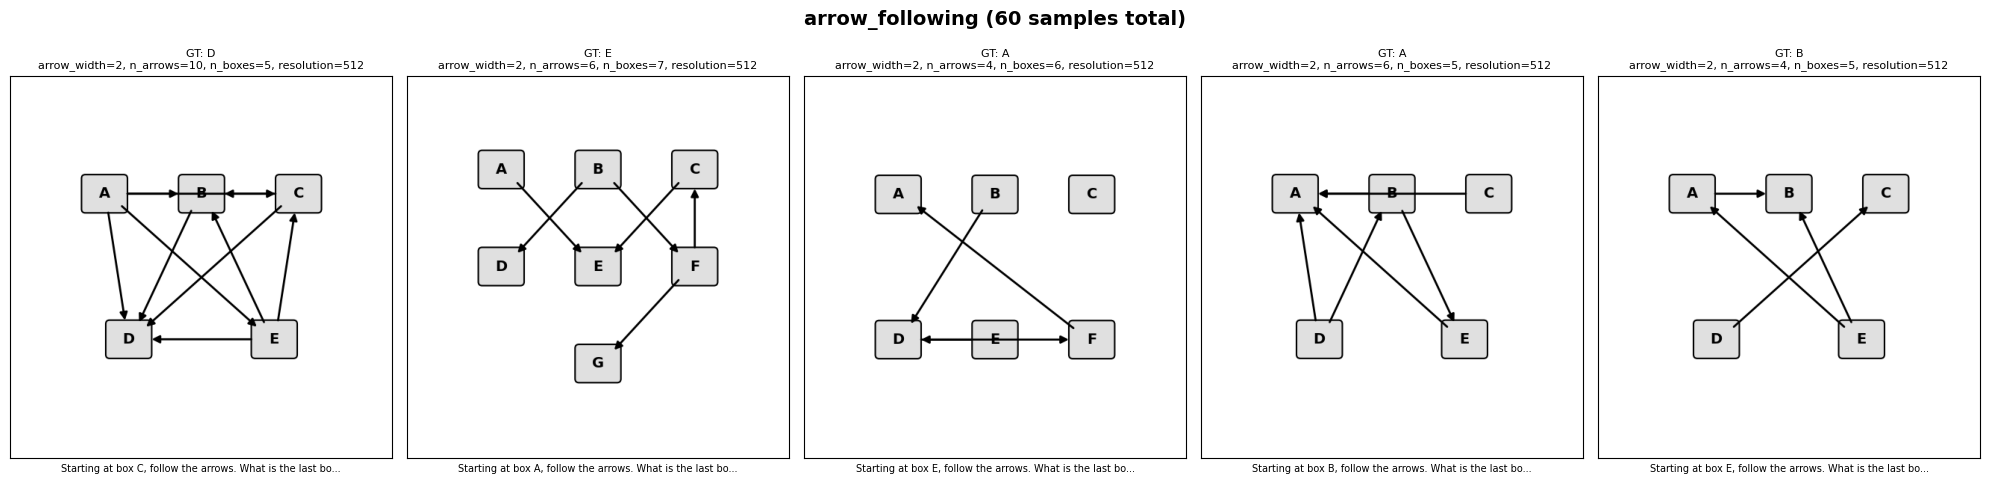

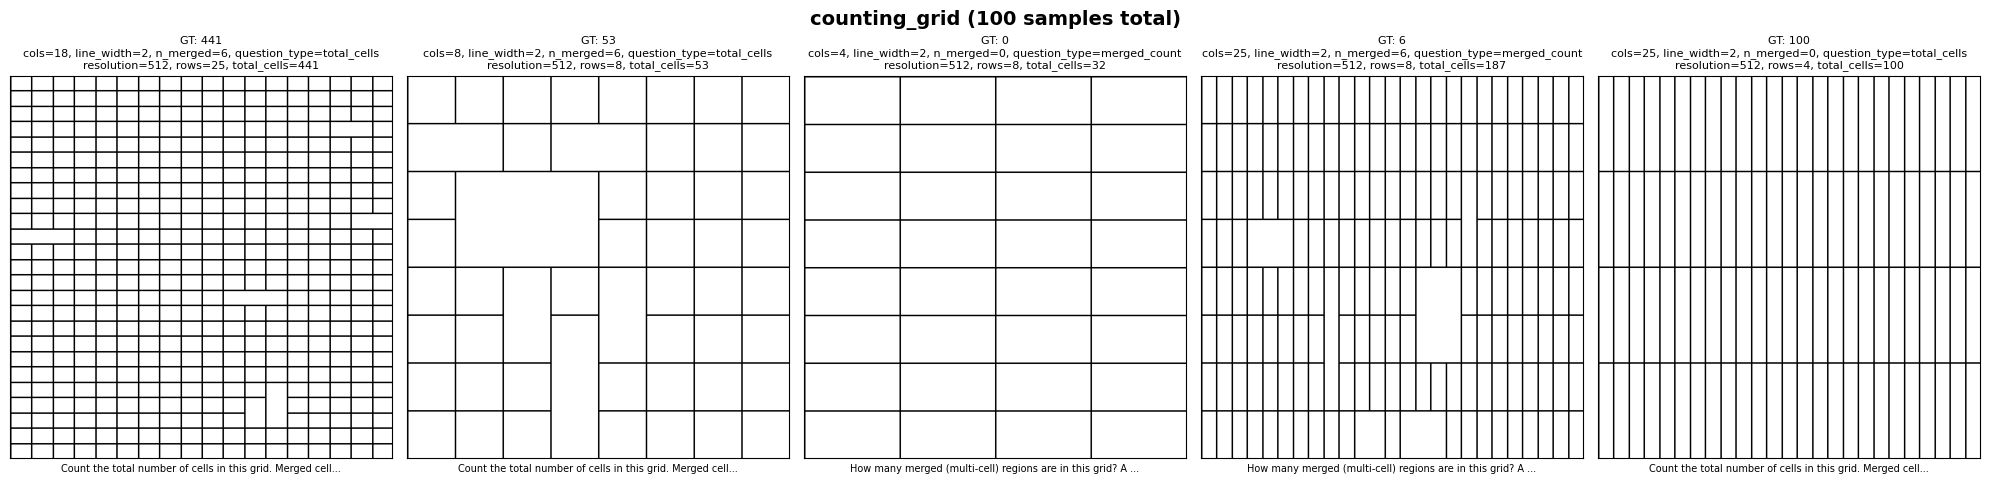

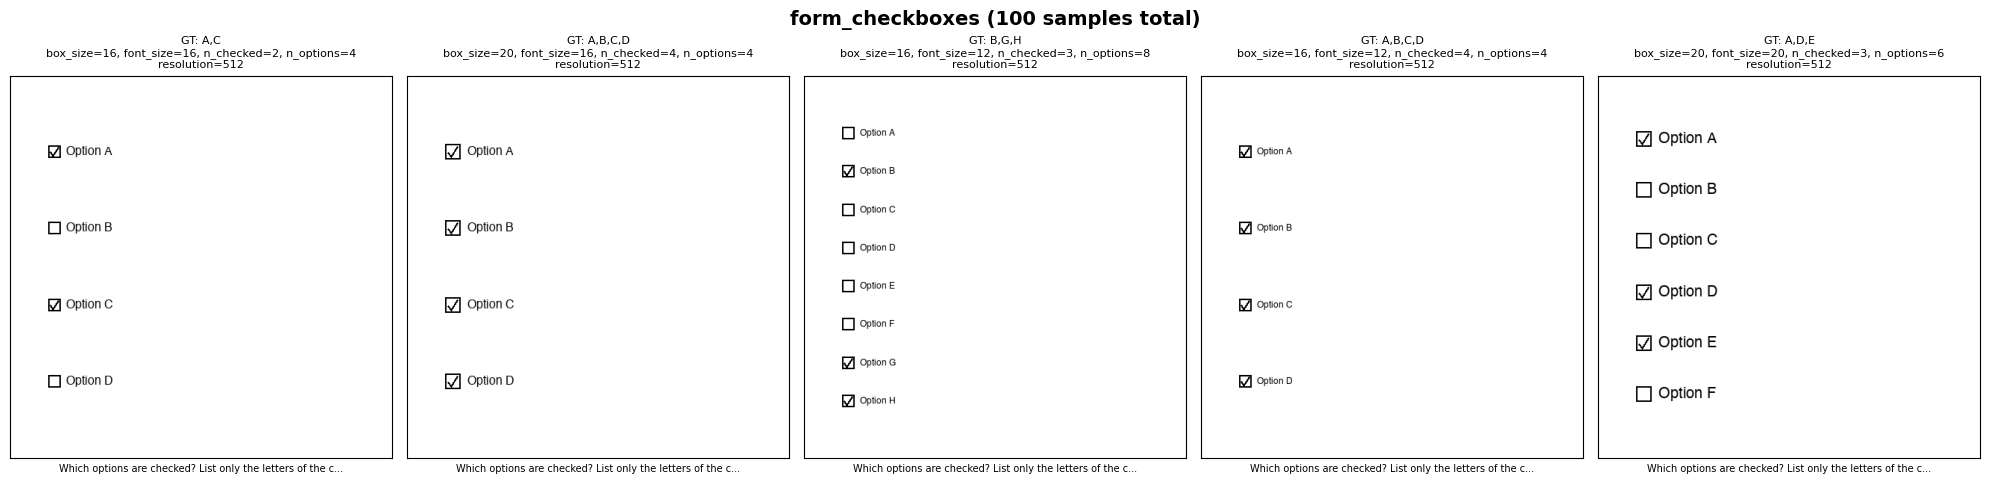

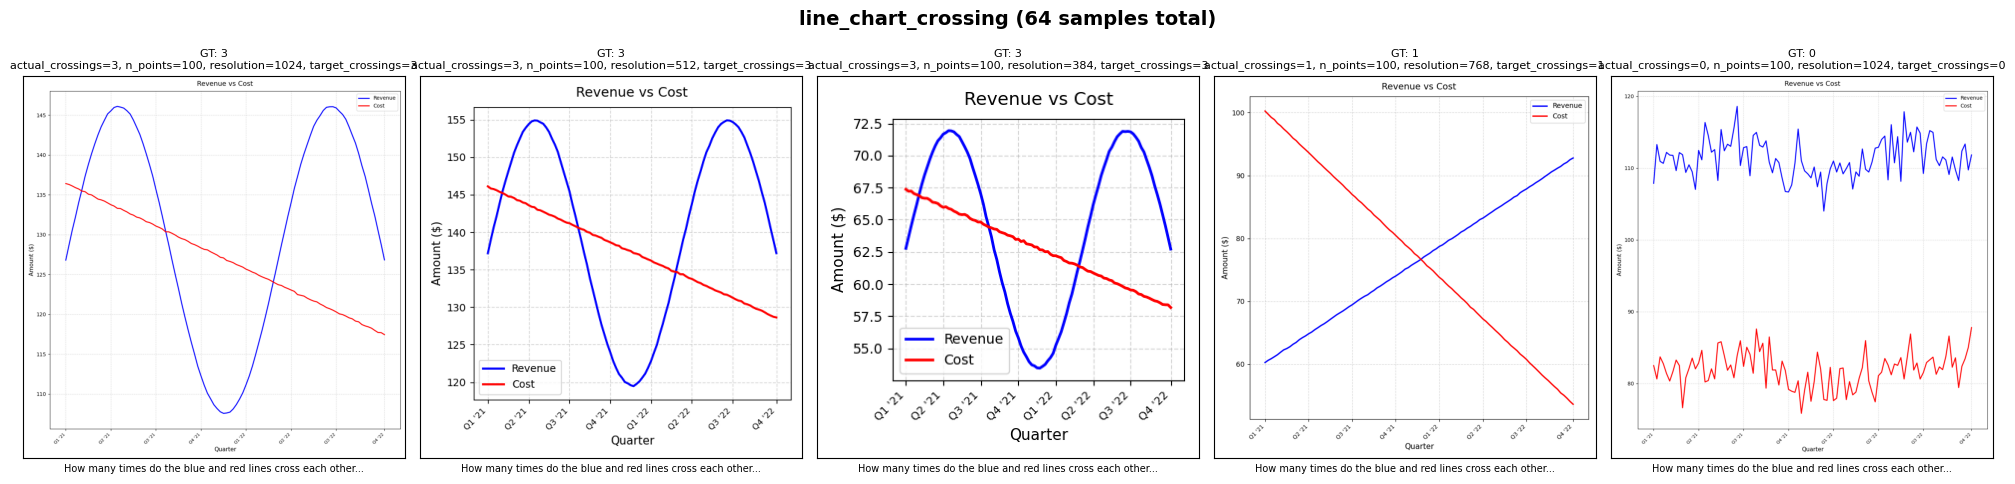

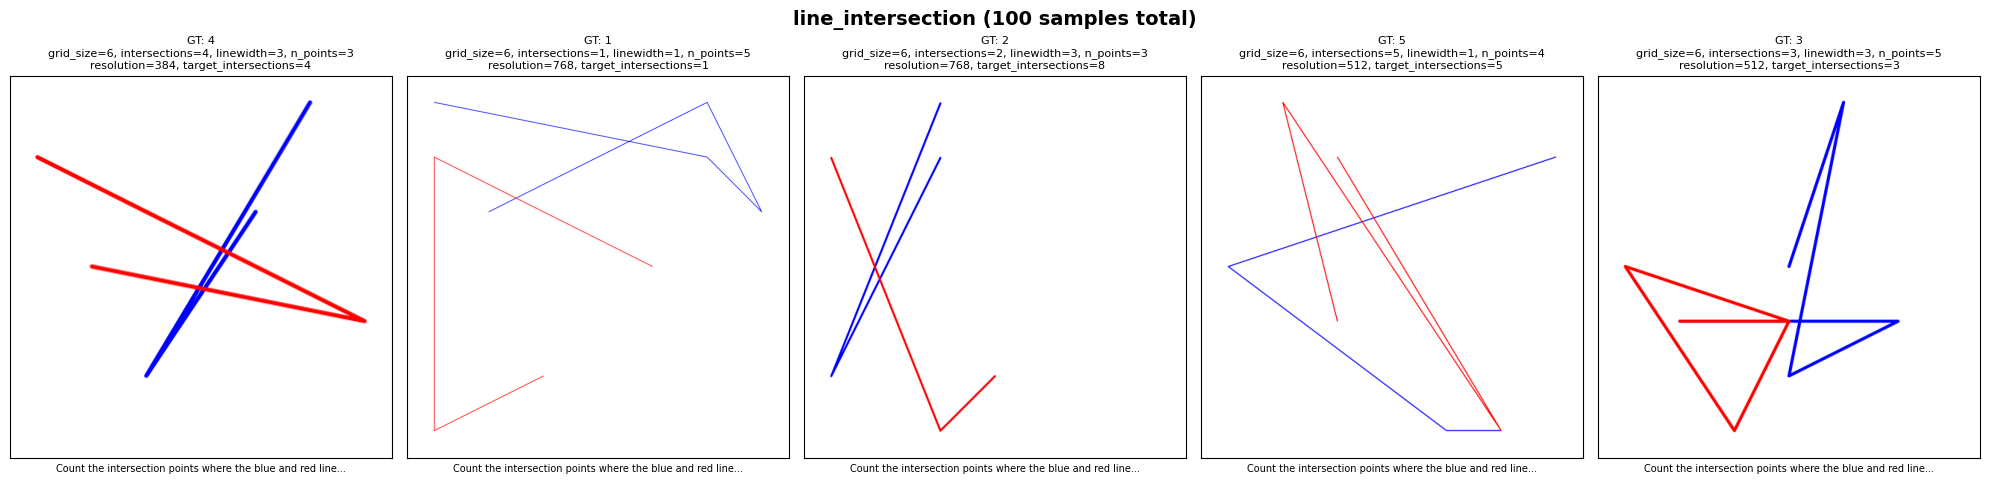

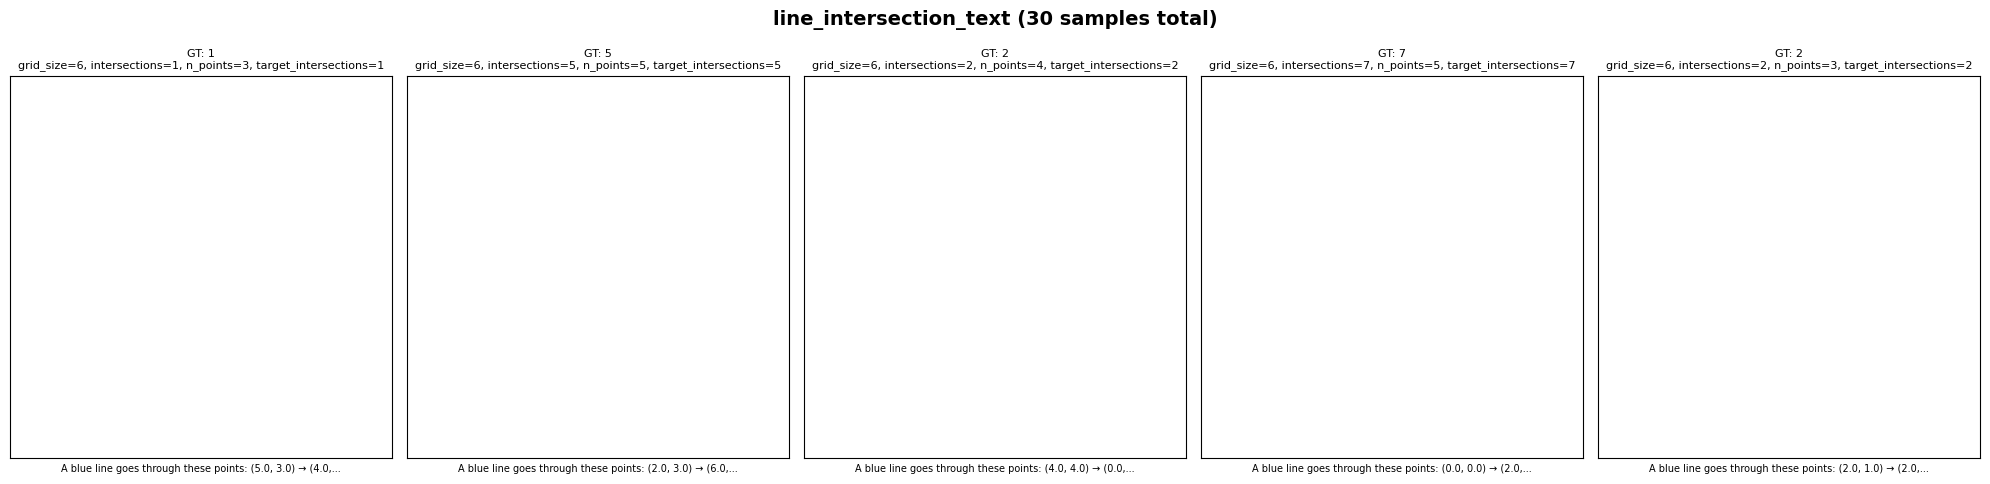

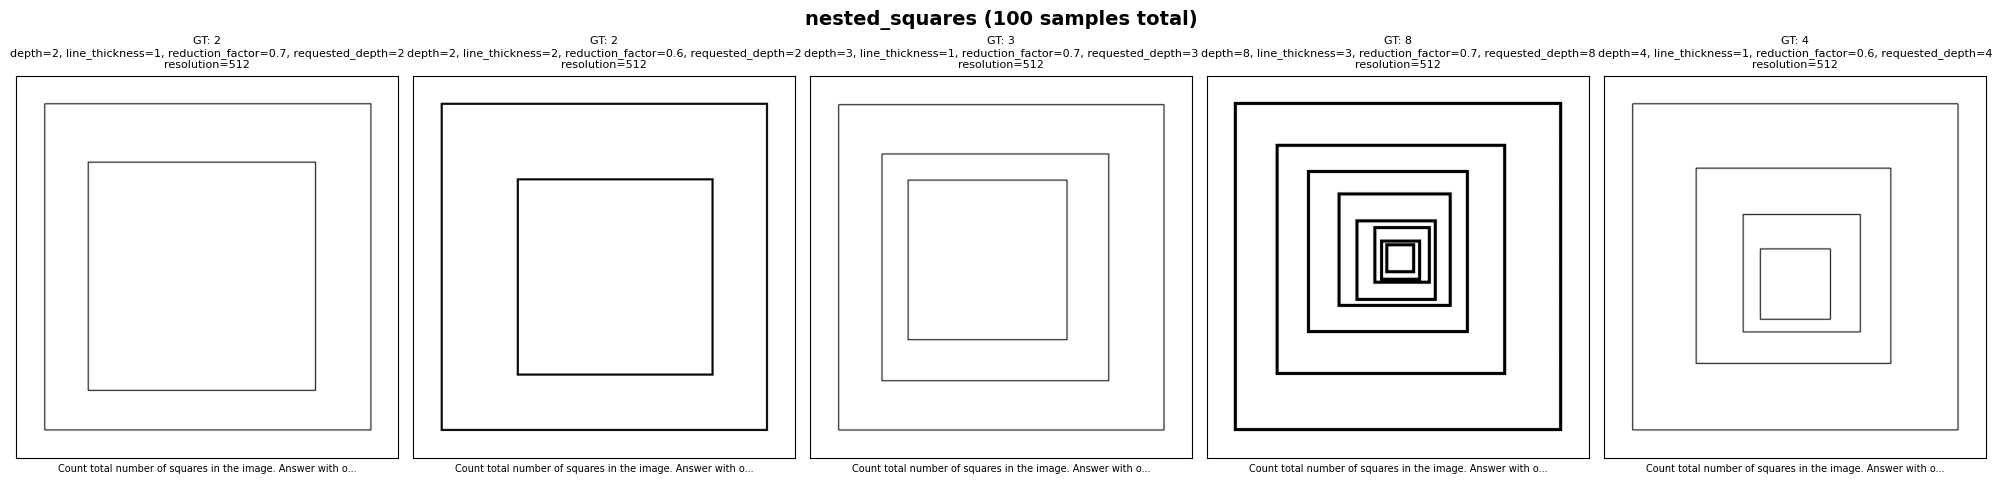

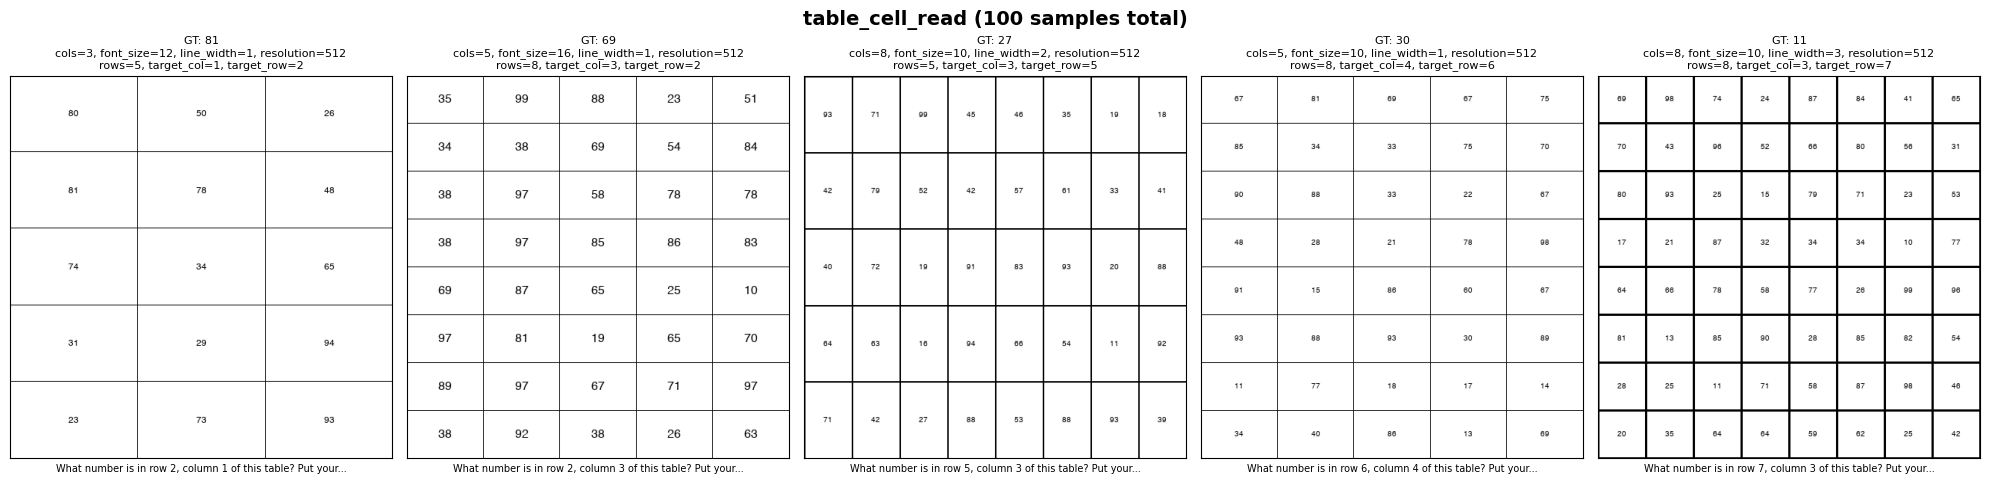

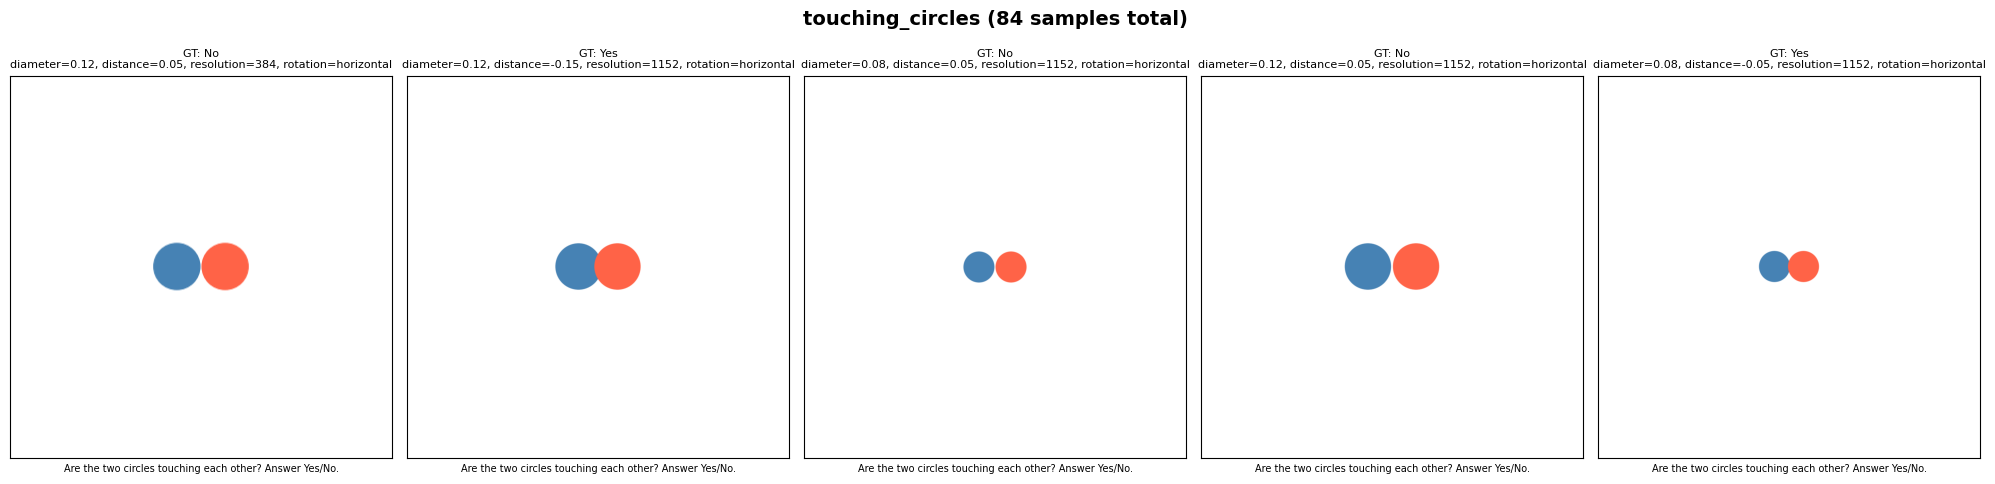

In [7]:
def select_diverse_samples(task_df, n=N_EXAMPLES):
    """Select samples that maximize parameter diversity."""
    if len(task_df) <= n:
        return task_df
    
    # Extract param columns that vary (skip list/dict columns)
    params = pd.json_normalize(task_df["params"].tolist())
    params.index = task_df.index
    varying = []
    for c in params.columns:
        if c in _SKIP_COLS:
            continue
        sample_val = params[c].dropna().iloc[0] if params[c].dropna().any() else None
        if isinstance(sample_val, (list, dict)):
            continue
        try:
            if params[c].nunique() > 1:
                varying.append(c)
        except TypeError:
            continue
    
    if not varying:
        return task_df.sample(n=n, random_state=42)
    
    # Create a param signature string for each sample
    sigs = params[varying].astype(str).agg("|".join, axis=1)
    
    # Pick one sample per unique signature, spread across params
    selected_idx = []
    sig_groups = sigs.groupby(sigs).apply(lambda x: x.index.tolist()).to_dict()
    sig_list = list(sig_groups.keys())
    random.shuffle(sig_list)
    
    # Take evenly spaced signatures
    step = max(1, len(sig_list) // n)
    for i in range(0, len(sig_list), step):
        if len(selected_idx) >= n:
            break
        group_indices = sig_groups[sig_list[i]]
        selected_idx.append(random.choice(group_indices))
    
    # Fill remaining slots if needed
    while len(selected_idx) < n and len(selected_idx) < len(task_df):
        remaining = [i for i in task_df.index if i not in selected_idx]
        selected_idx.append(random.choice(remaining))
    
    return task_df.loc[selected_idx]


for task in sorted(df["task_name"].unique()):
    task_df = df[df["task_name"] == task]
    samples = select_diverse_samples(task_df)
    
    n_show = len(samples)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    
    fig.suptitle(f"{task} ({len(task_df)} samples total)", fontsize=14, fontweight="bold")
    
    for ax, (_, row) in zip(axes, samples.iterrows()):
        img_path = row["image_path"]
        if Path(img_path).exists():
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Image\nnot found", ha="center", va="center", fontsize=12)
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Build annotation with key params
        params = row["params"] if isinstance(row["params"], dict) else {}
        param_strs = []
        for k, v in sorted(params.items()):
            if k in _SKIP_COLS or isinstance(v, (list, dict)):
                continue
            if isinstance(v, float):
                param_strs.append(f"{k}={v:.3g}")
            else:
                param_strs.append(f"{k}={v}")
        
        # Truncate prompt for display
        prompt = row["prompt"]
        if len(prompt) > 60:
            prompt = prompt[:57] + "..."
        
        title = f"GT: {row['ground_truth']}\n{', '.join(param_strs[:4])}"
        if len(param_strs) > 4:
            title += f"\n{', '.join(param_strs[4:8])}"
        ax.set_title(title, fontsize=8)
        ax.set_xlabel(prompt, fontsize=7, wrap=True)
    
    plt.tight_layout()
    plt.show()

## 5. Quick Quality Check

Spot-check: for each task, verify a random sample's image exists and matches expected dimensions.

In [5]:
for task in sorted(df["task_name"].unique()):
    task_df = df[df["task_name"] == task]
    sample = task_df.sample(1, random_state=42).iloc[0]
    img_path = Path(sample["image_path"])
    exists = img_path.exists()
    
    if exists:
        img = Image.open(img_path)
        size_str = f"{img.size[0]}x{img.size[1]}"
    else:
        size_str = "MISSING"
    
    params = sample["params"] if isinstance(sample["params"], dict) else {}
    expected_res = params.get("resolution", "?")
    
    status = "OK" if exists else "MISSING"
    print(f"{task:30s} | {status:7s} | {size_str:12s} | expected_res={expected_res} | GT={sample['ground_truth']}")

arrow_following                | OK      | 512x512      | expected_res=512 | GT=B
counting_grid                  | OK      | 512x512      | expected_res=512 | GT=8,4
form_checkboxes                | OK      | 512x512      | expected_res=512 | GT=A,D,E,F
line_chart_crossing            | OK      | 1024x1024    | expected_res=1024 | GT=1
line_intersection              | OK      | 768x768      | expected_res=768 | GT=8
line_intersection_text         | OK      | 64x64        | expected_res=? | GT=0
nested_squares                 | OK      | 512x512      | expected_res=512 | GT=5
table_cell_read                | OK      | 512x512      | expected_res=512 | GT=87
touching_circles               | OK      | 768x768      | expected_res=768 | GT=No
